# MCMC-ABC — Diagnostic exhaustif multi-datasets

**Objectif** : mesurer les propriétés de l'algorithme MCMC-ABC
en moyennant sur plusieurs datasets observés indépendants, pour distinguer :
  - la variabilité due à la chaîne MCMC (std Monte Carlo)
  - la variabilité due au choix du dataset (std inter-datasets)

**Organisation** :
1. Configuration globale
2. Fonctions utilitaires de diagnostic
3. Génération des N_DATASETS datasets observés
4. Run baseline multi-datasets
5. Sensibilité à ε
6. Sensibilité aux pas de proposition δ
7. Temps de calcul
8. Tableau récapitulatif

## 1. Configuration globale

**Toutes les variables de contrôle sont ici.**

In [1]:
import jax
import jax.numpy as jnp
from jax import random, vmap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import time
import pandas as pd
from IPython.display import display

from MCMC_ABC import (
    generate_observed_data,
    wasserstein1,
    log_prior,
    simulate,
    propose,
    make_mcmc_abc,
    find_valid_init,
    run_all_chains,
    compute_acf,
    TRUE_MU, TRUE_SIGMA, L,
    M_OBS, M_SIM,
    N_CHAINS, N_BURN, N_ITER, K_THIN,
    EPSILON, S_PRIOR, T_PRIOR
)

# Nombre de datasets observés indépendants.
N_DATASETS = 1

# Sections à exécuter. Mettre False pour sauter une section.
SECTIONS_TO_RUN = {
    "baseline":          True,
    "scan_epsilon":      True,
    "scan_delta":        True,
    "scan_mobs":         True,
    "scaling_time":      True,
    "summary_table":     True,
}

# Grilles des scans
N_EPSILONS  = 20    # nombre de valeurs de ε dans le scan
N_DELTAS    = 20    # nombre de valeurs de δ dans le scan
N_MOBS_VALS = 300    # nombre de valeurs de M_OBS dans le scan
N_NITER_SCALING = 20   # points pour le scaling N_ITER
N_NCHAINS_SCALING = 24 # points pour le scaling N_CHAINS

# Key générale
KEY_MASTER = random.PRNGKey(42)
key_datasets, KEY_RUN = random.split(KEY_MASTER)

# Génération de N_DATASETS datasets observés indépendants
keys_obs = random.split(key_datasets, N_DATASETS)
DATASETS = []
for i in range(N_DATASETS):
    y = generate_observed_data(keys_obs[i], TRUE_MU, TRUE_SIGMA, M_OBS, L)
    DATASETS.append({
        "y_obs":        y,
        "y_obs_sorted": jnp.sort(y),
        "mean":         float(jnp.mean(y)),
        "std":          float(jnp.std(y)),
    })

print(f"{'─'*60}")
print(f"  Configuration multi-datasets")
print(f"{'─'*60}")
print(f"  N_DATASETS   = {N_DATASETS}")
print(f"  M_OBS        = {M_OBS}")
print(f"  TRUE_MU      = {TRUE_MU}  |  TRUE_SIGMA = {TRUE_SIGMA}")
print(f"  N_CHAINS     = {N_CHAINS}  |  N_ITER     = {N_ITER}")
print(f"  EPSILON      = {EPSILON}")
print(f"{'─'*60}")
print(f"\n  Statistiques des {N_DATASETS} datasets :")
means = [d["mean"] for d in DATASETS]
stds  = [d["std"]  for d in DATASETS]
print(f"  mean(Y_obs) : {np.mean(means):.3f} ± {np.std(means):.3f}  "
      f"[min={np.min(means):.3f}, max={np.max(means):.3f}]")
print(f"  std(Y_obs)  : {np.mean(stds):.3f} ± {np.std(stds):.3f}  "
      f"[min={np.min(stds):.3f}, max={np.max(stds):.3f}]")
print(f"\n  Sections actives : "
      f"{[k for k,v in SECTIONS_TO_RUN.items() if v]}")

────────────────────────────────────────────────────────────
  Configuration multi-datasets
────────────────────────────────────────────────────────────
  N_DATASETS   = 1
  M_OBS        = 1000
  TRUE_MU      = 0.0  |  TRUE_SIGMA = 0.3
  N_CHAINS     = 8  |  N_ITER     = 20000
  EPSILON      = 0.1
────────────────────────────────────────────────────────────

  Statistiques des 1 datasets :
  mean(Y_obs) : 10.442 ± 0.000  [min=10.442, max=10.442]
  std(Y_obs)  : 0.985 ± 0.000  [min=0.985, max=0.985]

  Sections actives : ['baseline', 'scan_epsilon', 'scan_delta', 'scan_mobs', 'scaling_time', 'summary_table']


## 2. Fonctions utilitaires de diagnostic

In [2]:
def r_hat(chains):
    """
    Statistique de Gelman-Rubin (R-hat).
    Mesure si plusieurs chaines convergent vers la même distribution.
    Doit être proche de 1. Si > 1.1, pas encore de convergence.
    """
    n = chains.shape[1]
    m = chains.shape[0]
    W = jnp.mean(jnp.var(chains, axis=1, ddof=1))
    B = n * jnp.var(jnp.mean(chains, axis=1), ddof=1)
    var_hat = (1 - 1/n) * W + B/n
    return float(jnp.sqrt(var_hat / W))


def compute_ess(x, max_lag=200):
    """
    Effective Sample Size (ESS) sur une série 1D.
    ESS = N / (1 + 2 * sum_k ACF(k))
    """
    x = jnp.array(x)
    acf = compute_acf(x, max_lag=max_lag)
    acf_np = np.array(acf)
    cutoff = np.argmax(acf_np < 0)
    if cutoff == 0:
        cutoff = max_lag
    ess = len(x) / (1 + 2 * np.sum(acf_np[:cutoff]))
    return float(np.clip(ess, 1, len(x)))


def compute_all_metrics(chains_post, acc_rates, true_mu=TRUE_MU, true_sigma=TRUE_SIGMA):
    """
    Calcule l'ensemble des métriques de diagnostic sur un run unique.

    TROIS TYPES D'ÉCART-TYPE:

    (A) std_posterior_mu :
        Calculé sur les N_CHAINS * N_ITER échantillons poolés.
        Mesure la LARGEUR DU POSTERIOR (l'incertitude sur mu elle-même).
        Ne diminue pas avec plus d'itérations MCMC.
        Diminue avec plus de données ou un ε plus petit.

    (B) std_mc_median_mu :
        Calculé sur les N_CHAINS médianes (une par chaîne).
        Mesure l'INCERTITUDE DE MONTE CARLO (stabilité de l'estimateur).
        Diminue avec plus d'itérations ou plus de chaînes.

    (C) std_datasets_* (calculé en dehors, dans aggregate_metrics_over_datasets) :
        Calculé sur les N_DATASETS médianes (une par dataset).
        Mesure la VARIABILITÉ DUE AU CHOIX DU DATASET (robustesse aux données).
        Ne peut être estimé qu'avec N_DATASETS > 1.
    """
    n_chains, n_iter, _ = chains_post.shape

    flat_mu    = np.array(chains_post[:, :, 0]).ravel()
    flat_sigma = np.array(chains_post[:, :, 1]).ravel()

    medians_mu_per_chain    = np.median(np.array(chains_post[:, :, 0]), axis=1)
    medians_sigma_per_chain = np.median(np.array(chains_post[:, :, 1]), axis=1)
    means_mu_per_chain      = np.mean(np.array(chains_post[:, :, 0]), axis=1)
    means_sigma_per_chain   = np.mean(np.array(chains_post[:, :, 1]), axis=1)

    q025_mu,  q50_mu,  q975_mu  = np.percentile(flat_mu,    [2.5, 50, 97.5])
    q025_sig, q50_sig, q975_sig = np.percentile(flat_sigma,  [2.5, 50, 97.5])

    ess_mu    = compute_ess(chains_post[0, :, 0])
    ess_sigma = compute_ess(chains_post[0, :, 1])

    rhat_mu    = r_hat(jnp.array(chains_post[:, :, 0]))
    rhat_sigma = r_hat(jnp.array(chains_post[:, :, 1]))

    acc_mean = float(jnp.mean(acc_rates))
    acc_std  = float(jnp.std(acc_rates))

    return {
        "bias_mu"             : float(q50_mu - true_mu),
        "bias_sigma"          : float(q50_sig - true_sigma),
        "std_posterior_mu"    : float(np.std(flat_mu)),
        "std_posterior_sigma" : float(np.std(flat_sigma)),
        "std_mc_median_mu"    : float(np.std(medians_mu_per_chain)),
        "std_mc_median_sigma" : float(np.std(medians_sigma_per_chain)),
        "std_mc_mean_mu"      : float(np.std(means_mu_per_chain)),
        "std_mc_mean_sigma"   : float(np.std(means_sigma_per_chain)),
        "ic95_mu"             : (float(q025_mu),  float(q975_mu)),
        "ic95_sigma"          : (float(q025_sig), float(q975_sig)),
        "ic95_width_mu"       : float(q975_mu  - q025_mu),
        "ic95_width_sigma"    : float(q975_sig - q025_sig),
        "median_mu"           : float(q50_mu),
        "median_sigma"        : float(q50_sig),
        "mean_mu"             : float(np.mean(flat_mu)),
        "mean_sigma"          : float(np.mean(flat_sigma)),
        "rhat_mu"             : rhat_mu,
        "rhat_sigma"          : rhat_sigma,
        "ess_mu"              : ess_mu,
        "ess_sigma"           : ess_sigma,
        "ess_ratio_mu"        : ess_mu    / (n_iter * n_chains),
        "ess_ratio_sigma"     : ess_sigma / (n_iter * n_chains),
        "acc_mean"            : acc_mean,
        "acc_std"             : acc_std,
        "n_samples_total"     : n_chains * n_iter,
    }


def aggregate_metrics_over_datasets(list_of_metrics):
    """
    Agrège une liste de métriques (une par dataset) en une seule structure.

    Pour chaque clé scalaire, calcule :
      - _mean  : moyenne sur les N_DATASETS
      - _std_mc  : std de Monte Carlo (moyenne des stds par chaîne, intra-dataset)
      - _std_ds  : std inter-datasets (std des médianes entre datasets)
                   nouvelle quantité, non estimable avec 1 seul dataset

    La _std_ds mesure la sensibilité de la métrique au tirage de Y_OBS.
    Si _std_ds >> _std_mc, l'incertitude vient principalement des données.
    Si _std_mc >> _std_ds, augmenter N_ITER/N_CHAINS serait plus utile.

    Si N_DATASETS == 1 : _std_ds = NaN (non estimable).
    """
    if len(list_of_metrics) == 0:
        return {}

    keys = [k for k in list_of_metrics[0].keys()
            if isinstance(list_of_metrics[0][k], (int, float))]

    agg = {}
    for k in keys:
        vals = np.array([m[k] for m in list_of_metrics if k in m])
        agg[f"{k}_mean"]   = float(np.mean(vals))
        agg[f"{k}_std_mc"] = float(np.mean([m.get(f"std_mc_median_mu", np.nan)
                                             for m in list_of_metrics]))
        # std inter-datasets : mesure la variabilité due au choix de Y_OBS
        if len(vals) > 1:
            agg[f"{k}_std_ds"] = float(np.std(vals, ddof=1))
        else:
            agg[f"{k}_std_ds"] = float("nan")

    # Intervalles de crédibilité : on agrège les bornes séparément
    for param in ["mu", "sigma"]:
        key_ic = f"ic95_{param}"
        lowers = [m[key_ic][0] for m in list_of_metrics if key_ic in m]
        uppers = [m[key_ic][1] for m in list_of_metrics if key_ic in m]
        agg[f"ic95_{param}_lower_mean"] = float(np.mean(lowers))
        agg[f"ic95_{param}_upper_mean"] = float(np.mean(uppers))
        agg[f"ic95_{param}_lower_std_ds"] = float(np.std(lowers, ddof=1)) if len(lowers) > 1 else float("nan")
        agg[f"ic95_{param}_upper_std_ds"] = float(np.std(uppers, ddof=1)) if len(uppers) > 1 else float("nan")

    agg["n_datasets"] = len(list_of_metrics)
    return agg


def run_on_all_datasets(dataset_list, epsilon, key_base, label=""):
    """
    Lance run_all_chains sur chaque dataset et retourne la liste des métriques.
    """
    all_metrics = []
    times = []
    key = key_base
    for i, ds in enumerate(dataset_list):
        key, k_init, k_run = random.split(key, 3)
        try:
            theta0, _ = find_valid_init(k_init, ds["y_obs_sorted"], epsilon)
            fn = make_mcmc_abc(ds["y_obs_sorted"], epsilon)
            t0 = time.perf_counter()
            chains, acc = run_all_chains(fn, k_run, theta0)
            elapsed = time.perf_counter() - t0
            m = compute_all_metrics(chains, acc)
            m["wall_time_s"] = elapsed
            m["dataset_idx"] = i
            all_metrics.append(m)
        except RuntimeError as e:
            print(f"  Dataset {i} échoué : {e}")
    if label:
        print(f"  {label} : {len(all_metrics)}/{len(dataset_list)} datasets réussis")
    return all_metrics


def print_aggregated_metrics(agg, title=""):
    """Affiche les métriques agrégées de façon lisible."""
    n_ds = agg.get("n_datasets", 1)
    sep = "═" * 65
    print(f"\n{sep}")
    if title:
        print(f"  {title}")
    print(f"  N_DATASETS = {n_ds}  "
          f"{'(std_ds non estimable)' if n_ds == 1 else ''}")
    print(sep)

    def fmt_row(label, key_mean, key_std_ds=None, key_std_mc=None, note=""):
        val = agg.get(key_mean, float("nan"))
        s   = f"  {label:<35} {val:+.4f}"
        if key_std_ds and not np.isnan(agg.get(key_std_ds, float("nan"))):
            s += f"   ±{agg[key_std_ds]:.4f} [inter-ds]"
        if key_std_mc and not np.isnan(agg.get(key_std_mc, float("nan"))):
            s += f"   ±{agg[key_std_mc]:.4f} [MC]"
        if note:
            s += f"   {note}"
        print(s)

    print("\n── Biais (médiane postérieure − vraie valeur) ─────────────")
    fmt_row("bias_mu", "bias_mu_mean", "bias_mu_std_ds",
            note=f"[vrai mu = {TRUE_MU}]")
    fmt_row("bias_sigma", "bias_sigma_mean", "bias_sigma_std_ds",
            note=f"[vrai sigma = {TRUE_SIGMA}]")
    print("  std inter-ds = variabilité due au choix de Y_OBS")
    print("  Si std_ds >> 0 : le biais dépend fortement du dataset tiré")

    print("\n── (A) Std du posterior — largeur de p(θ|Y_obs) ───────────")
    fmt_row("std_posterior_mu   (A)", "std_posterior_mu_mean",
            "std_posterior_mu_std_ds")
    fmt_row("std_posterior_sigma(A)", "std_posterior_sigma_mean",
            "std_posterior_sigma_std_ds")
    print("  → Varie d'un dataset à l'autre (std_ds mesure cette variation)")

    print("\n── (B) Std de Monte Carlo — stabilité de l'estimateur ─────")
    fmt_row("std_mc_median_mu   (B)", "std_mc_median_mu_mean",
            "std_mc_median_mu_std_ds")
    fmt_row("std_mc_median_sigma(B)", "std_mc_median_sigma_mean",
            "std_mc_median_sigma_std_ds")
    print("  → Doit être << std_posterior_mu pour que l'estimateur soit fiable")

    print("\n── Intervalles de crédibilité 95% (moyennes sur datasets) ─")
    lo_mu  = agg.get("ic95_mu_lower_mean",  float("nan"))
    hi_mu  = agg.get("ic95_mu_upper_mean",  float("nan"))
    lo_sig = agg.get("ic95_sigma_lower_mean", float("nan"))
    hi_sig = agg.get("ic95_sigma_upper_mean", float("nan"))
    w_mu   = agg.get("ic95_width_mu_mean",    float("nan"))
    w_sig  = agg.get("ic95_width_sigma_mean", float("nan"))
    print(f"  IC95 mu    = [{lo_mu:.3f}, {hi_mu:.3f}]  largeur={w_mu:.3f}")
    print(f"  IC95 sigma = [{lo_sig:.3f}, {hi_sig:.3f}]  largeur={w_sig:.3f}")
    lo_mu_ds  = agg.get("ic95_mu_lower_std_ds",  float("nan"))
    hi_mu_ds  = agg.get("ic95_mu_upper_std_ds",  float("nan"))
    if not np.isnan(lo_mu_ds):
        print(f"  Variabilité inter-ds : borne basse ±{lo_mu_ds:.3f}, "
              f"borne haute ±{hi_mu_ds:.3f}")

    print("\n── Convergence ─────────────────────────────────────────────")
    rhat_mu  = agg.get("rhat_mu_mean",    float("nan"))
    rhat_sig = agg.get("rhat_sigma_mean", float("nan"))
    ess_mu   = agg.get("ess_mu_mean",     float("nan"))
    ess_sig  = agg.get("ess_sigma_mean",  float("nan"))
    ess_r_mu = agg.get("ess_ratio_mu_mean", float("nan"))
    ess_r_sig= agg.get("ess_ratio_sigma_mean", float("nan"))
    print(f"  R-hat mu    = {rhat_mu:.4f}   "
          f"{'✓ OK' if rhat_mu < 1.01 else '✗ PROBLÈME'}"
          f"  (std_ds = {agg.get('rhat_mu_std_ds', float('nan')):.4f})")
    print(f"  R-hat sigma = {rhat_sig:.4f}   "
          f"{'✓ OK' if rhat_sig < 1.01 else '✗ PROBLÈME'}"
          f"  (std_ds = {agg.get('rhat_sigma_std_ds', float('nan')):.4f})")
    print(f"  ESS mu      = {ess_mu:.0f}  (ratio = {ess_r_mu:.3f})")
    print(f"  ESS sigma   = {ess_sig:.0f}  (ratio = {ess_r_sig:.3f})")

    print("\n── Acceptance rate ─────────────────────────────────────────")
    acc = agg.get("acc_mean_mean", float("nan"))
    acc_ds = agg.get("acc_mean_std_ds", float("nan"))
    print(f"  Moyenne = {acc:.3f}  ±{acc_ds:.3f} [inter-ds]")
    print("  Cible : 20–40%")

    t = agg.get("wall_time_s_mean", float("nan"))
    t_ds = agg.get("wall_time_s_std_ds", float("nan"))
    print(f"\n── Temps de calcul ─────────────────────────────────────────")
    print(f"  Temps moyen par dataset = {t:.1f}s  ±{t_ds:.1f}s [inter-ds]")
    print(f"  Temps total estimé      = {t * n_ds:.1f}s")
    print()


print("Fonctions utilitaires chargées.")

Fonctions utilitaires chargées.


## 3. Run baseline — métriques agrégées sur N_DATASETS

In [3]:
if SECTIONS_TO_RUN["baseline"]:
    print(f"{'─'*60}")
    print(f"  SECTION BASELINE — {N_DATASETS} dataset(s)")
    print(f"{'─'*60}")

    # Initialisation commune (theta0 trouvé sur le premier dataset)
    theta0_base, key_run_base = find_valid_init(
        KEY_RUN, DATASETS[0]["y_obs_sorted"], EPSILON
    )
    print(f"  theta0 de référence = "
          f"(mu={float(theta0_base[0]):.3f}, sigma={float(theta0_base[1]):.3f})")

    t_total = time.perf_counter()
    metrics_per_dataset_base = run_on_all_datasets(
        DATASETS, EPSILON, key_run_base, label="Baseline"
    )
    elapsed_total = time.perf_counter() - t_total

    agg_base = aggregate_metrics_over_datasets(metrics_per_dataset_base)
    agg_base["wall_time_total_s"] = elapsed_total

    print_aggregated_metrics(
        agg_base,
        title=f"BASELINE  ε={EPSILON}  N_ITER={N_ITER}  "
              f"N_CHAINS={N_CHAINS}  N_DATASETS={N_DATASETS}"
    )
    print(f"  Temps total (tous datasets) : {elapsed_total:.1f}s")

    # Visualisation: Distribution des médianes par dataset
    if N_DATASETS > 1:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(
            f"Distribution des médianes posteriors sur {N_DATASETS} datasets",
            fontsize=11, fontweight="bold"
        )
        medians_mu    = [m["median_mu"]    for m in metrics_per_dataset_base]
        medians_sigma = [m["median_sigma"] for m in metrics_per_dataset_base]

        for ax, vals, name, true_val in zip(
            axes,
            [medians_mu, medians_sigma],
            ["μ", "σ"],
            [TRUE_MU, TRUE_SIGMA]
        ):
            ax.hist(vals, bins=max(5, N_DATASETS // 3), color="steelblue",
                    edgecolor="white", alpha=0.8)
            ax.axvline(true_val, color="red", lw=2, ls="--",
                       label=f"Vraie valeur = {true_val}")
            ax.axvline(np.mean(vals), color="orange", lw=1.5, ls="-",
                       label=f"Médiane moyenne = {np.mean(vals):.3f}")
            ax.set_title(f"Médiane posterior de {name}", fontweight="bold")
            ax.set_xlabel(f"Médiane de {name}")
            ax.legend(fontsize=8)
            ax.text(0.98, 0.95,
                    f"std inter-ds = {np.std(vals, ddof=1):.4f}",
                    transform=ax.transAxes, ha="right", va="top",
                    fontsize=8,
                    bbox=dict(boxstyle="round", fc="white", alpha=0.8))

        plt.tight_layout()
        plt.savefig("MCMC-ABC_plots/baseline_multids_medians.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

────────────────────────────────────────────────────────────
  SECTION BASELINE — 1 dataset(s)
────────────────────────────────────────────────────────────
  theta0 de référence = (mu=-0.003, sigma=0.289)
  Baseline : 1/1 datasets réussis

═════════════════════════════════════════════════════════════════
  BASELINE  ε=0.1  N_ITER=20000  N_CHAINS=8  N_DATASETS=1
  N_DATASETS = 1  (std_ds non estimable)
═════════════════════════════════════════════════════════════════

── Biais (médiane postérieure − vraie valeur) ─────────────
  bias_mu                             -0.0004   [vrai mu = 0.0]
  bias_sigma                          -0.0026   [vrai sigma = 0.3]
  std inter-ds = variabilité due au choix de Y_OBS
  Si std_ds >> 0 : le biais dépend fortement du dataset tiré

── (A) Std du posterior — largeur de p(θ|Y_obs) ───────────
  std_posterior_mu   (A)              +0.0077
  std_posterior_sigma(A)              +0.0180
  → Varie d'un dataset à l'autre (std_ds mesure cette variation)

── (B)

## 4. Sensibilité à ε — scan multi-datasets

Pour chaque valeur de ε et chaque dataset, on lance les chaînes.
Les courbes affichent la moyenne sur les datasets ± bande d'incertitude inter-datasets.

**Deux bandes sont distinguées :**
- Bande MC (bleue claire) : std de Monte Carlo, déjà présente avec 1 dataset
- Bande inter-datasets (gris) : variabilité due au choix de Y_OBS (nouvelle)

────────────────────────────────────────────────────────────
  SECTION SCAN ε — 1 dataset(s) × 20 valeurs
────────────────────────────────────────────────────────────


Scan ε: 100%|██████████| 20/20 [21:50<00:00, 65.54s/it]



  Valeurs ε avec au moins 1 run réussi : 18 / 20


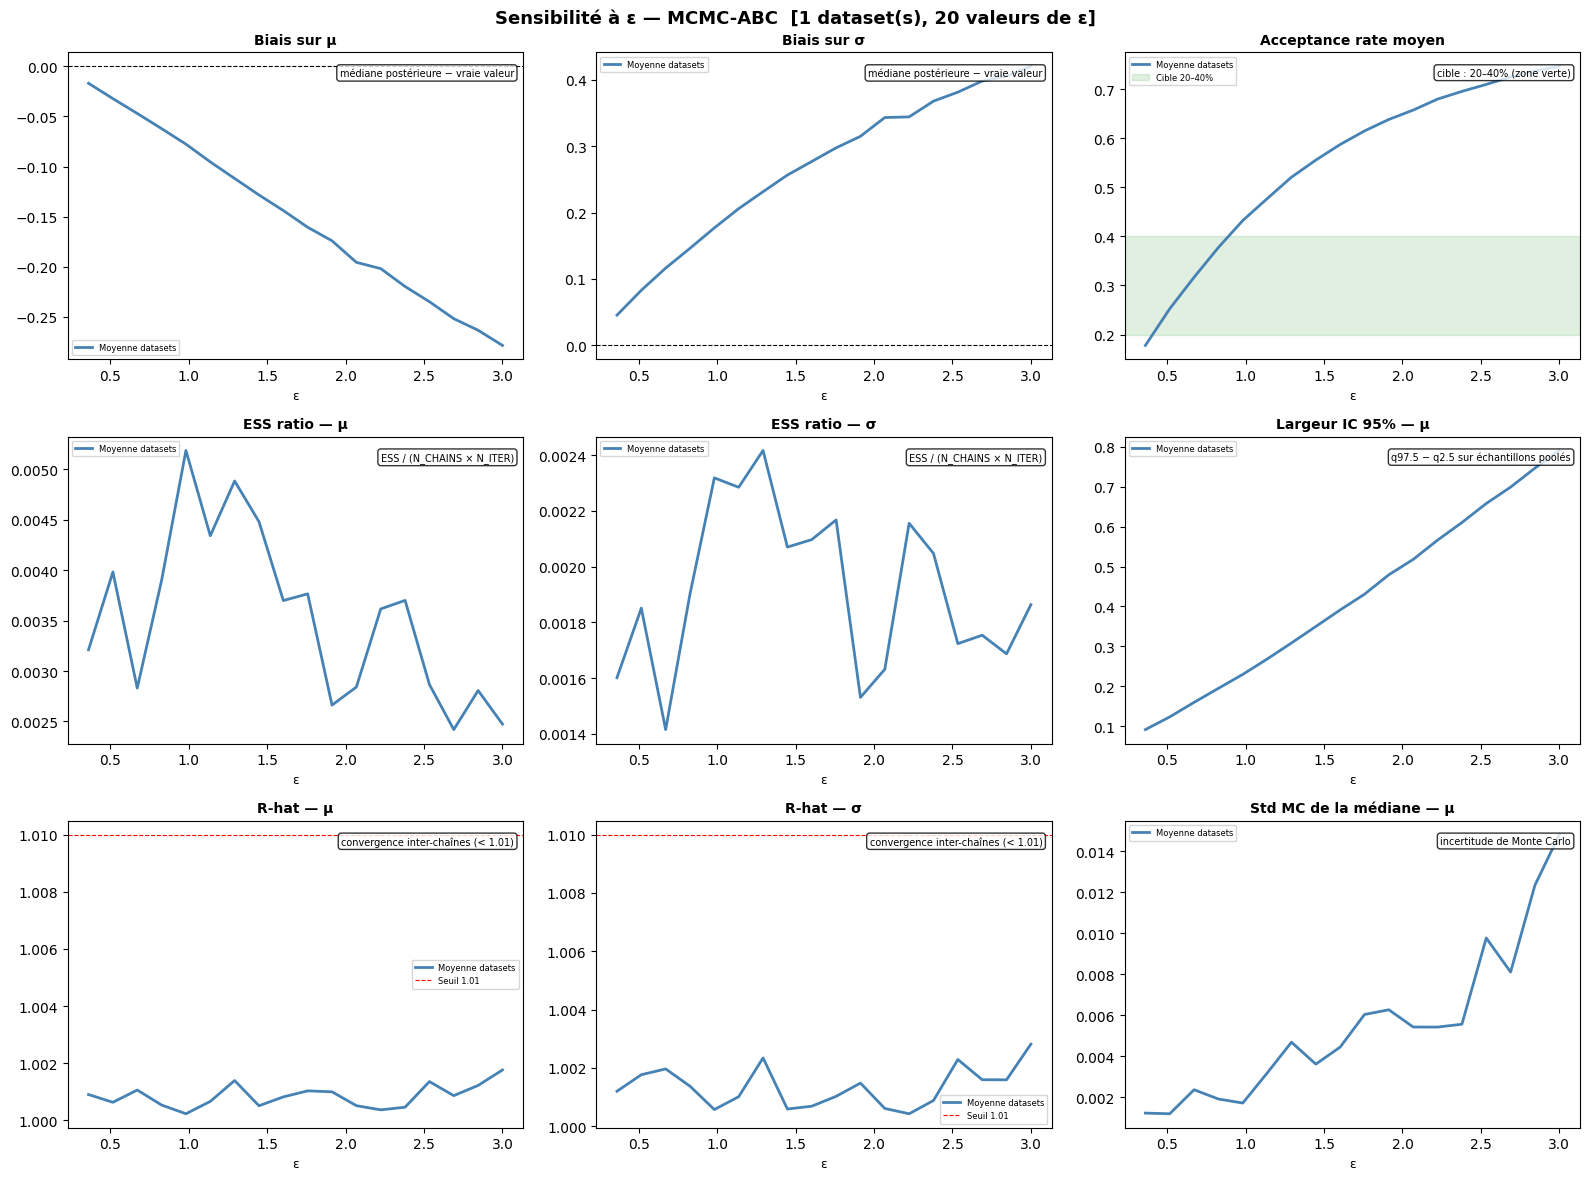

In [4]:
if SECTIONS_TO_RUN["scan_epsilon"]:
    print(f"{'─'*60}")
    print(f"  SECTION SCAN ε — {N_DATASETS} dataset(s) × {N_EPSILONS} valeurs")
    print(f"{'─'*60}")

    EPSILONS = np.linspace(0.05, 3.0, N_EPSILONS)
    results_eps = []   # liste de dicts : une entrée par (epsilon, dataset)
    key_scan_eps = random.PRNGKey(100)

    for eps in tqdm(EPSILONS, desc="Scan ε"):
        key_scan_eps, k_base = random.split(key_scan_eps)
        per_ds = []
        k = k_base
        for ds in DATASETS:
            k, k_init, k_run = random.split(k, 3)
            try:
                theta0_eps, _ = find_valid_init(
                    k_init, ds["y_obs_sorted"], float(eps), n_tries=5_000
                )
                fn_eps = make_mcmc_abc(ds["y_obs_sorted"], float(eps))
                t0 = time.perf_counter()
                chains_eps, acc_eps = run_all_chains(fn_eps, k_run, theta0_eps)
                elapsed = time.perf_counter() - t0
                m = compute_all_metrics(chains_eps, acc_eps)
                m["wall_time_s"] = elapsed
                per_ds.append(m)
            except RuntimeError:
                pass

        if len(per_ds) == 0:
            results_eps.append({"epsilon": float(eps), "success": False})
            continue

        agg = aggregate_metrics_over_datasets(per_ds)
        agg["epsilon"]  = float(eps)
        agg["n_success"] = len(per_ds)
        agg["success"]  = True
        results_eps.append(agg)

    df_eps = pd.DataFrame([r for r in results_eps if r.get("success", False)])
    print(f"\n  Valeurs ε avec au moins 1 run réussi : {len(df_eps)} / {N_EPSILONS}")

    # Plot
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle(
        f"Sensibilité à ε — MCMC-ABC  "
        f"[{N_DATASETS} dataset(s), {N_EPSILONS} valeurs de ε]",
        fontsize=13, fontweight="bold"
    )

    eps_vals = df_eps["epsilon"].values

    plots_eps = [
        (axes[0,0], "bias_mu",          "Biais sur μ",
         "médiane postérieure − vraie valeur"),
        (axes[0,1], "bias_sigma",       "Biais sur σ",
         "médiane postérieure − vraie valeur"),
        (axes[0,2], "acc_mean",         "Acceptance rate moyen",
         "cible : 20–40% (zone verte)"),
        (axes[1,0], "ess_ratio_mu",     "ESS ratio — μ",
         "ESS / (N_CHAINS × N_ITER)"),
        (axes[1,1], "ess_ratio_sigma",  "ESS ratio — σ",
         "ESS / (N_CHAINS × N_ITER)"),
        (axes[1,2], "ic95_width_mu",    "Largeur IC 95% — μ",
         "q97.5 − q2.5 sur échantillons poolés"),
        (axes[2,0], "rhat_mu",          "R-hat — μ",
         "convergence inter-chaînes (< 1.01)"),
        (axes[2,1], "rhat_sigma",       "R-hat — σ",
         "convergence inter-chaînes (< 1.01)"),
        (axes[2,2], "std_mc_median_mu", "Std MC de la médiane — μ",
         "incertitude de Monte Carlo"),
    ]

    for ax, col, title, desc in plots_eps:
        col_mean   = f"{col}_mean"
        col_std_ds = f"{col}_std_ds"
        col_std_mc = f"{col}_std_mc"

        if col_mean not in df_eps.columns:
            ax.set_visible(False)
            continue

        y    = df_eps[col_mean].values
        ax.plot(eps_vals, y, lw=2, color="steelblue", label="Moyenne datasets")

        # Bande inter-datasets (variabilité due au choix de Y_OBS)
        if col_std_ds in df_eps.columns and N_DATASETS > 1:
            sd = df_eps[col_std_ds].values
            ax.fill_between(eps_vals, y - sd, y + sd,
                            alpha=0.25, color="steelblue",
                            label="± std inter-datasets")

        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("ε", fontsize=9)
        ax.text(0.98, 0.95, desc, transform=ax.transAxes,
                fontsize=7, ha="right", va="top",
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))

        if col == "acc_mean":
            ax.axhspan(0.20, 0.40, alpha=0.12, color="green",
                       label="Cible 20–40%")
        if "bias" in col:
            ax.axhline(0, color="k", lw=0.8, ls="--")
        if "rhat" in col:
            ax.axhline(1.01, color="red", lw=0.8, ls="--", label="Seuil 1.01")

        ax.legend(fontsize=6)

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/sensitivity_epsilon_multids.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 5. Sensibilité aux pas de proposition δ — scan multi-datasets

────────────────────────────────────────────────────────────
  SECTION SCAN δ — 1 dataset(s) × 20 valeurs
────────────────────────────────────────────────────────────


Scan δ: 100%|██████████| 20/20 [10:56<00:00, 32.81s/it]


  Scan δ terminé. 20 configurations.


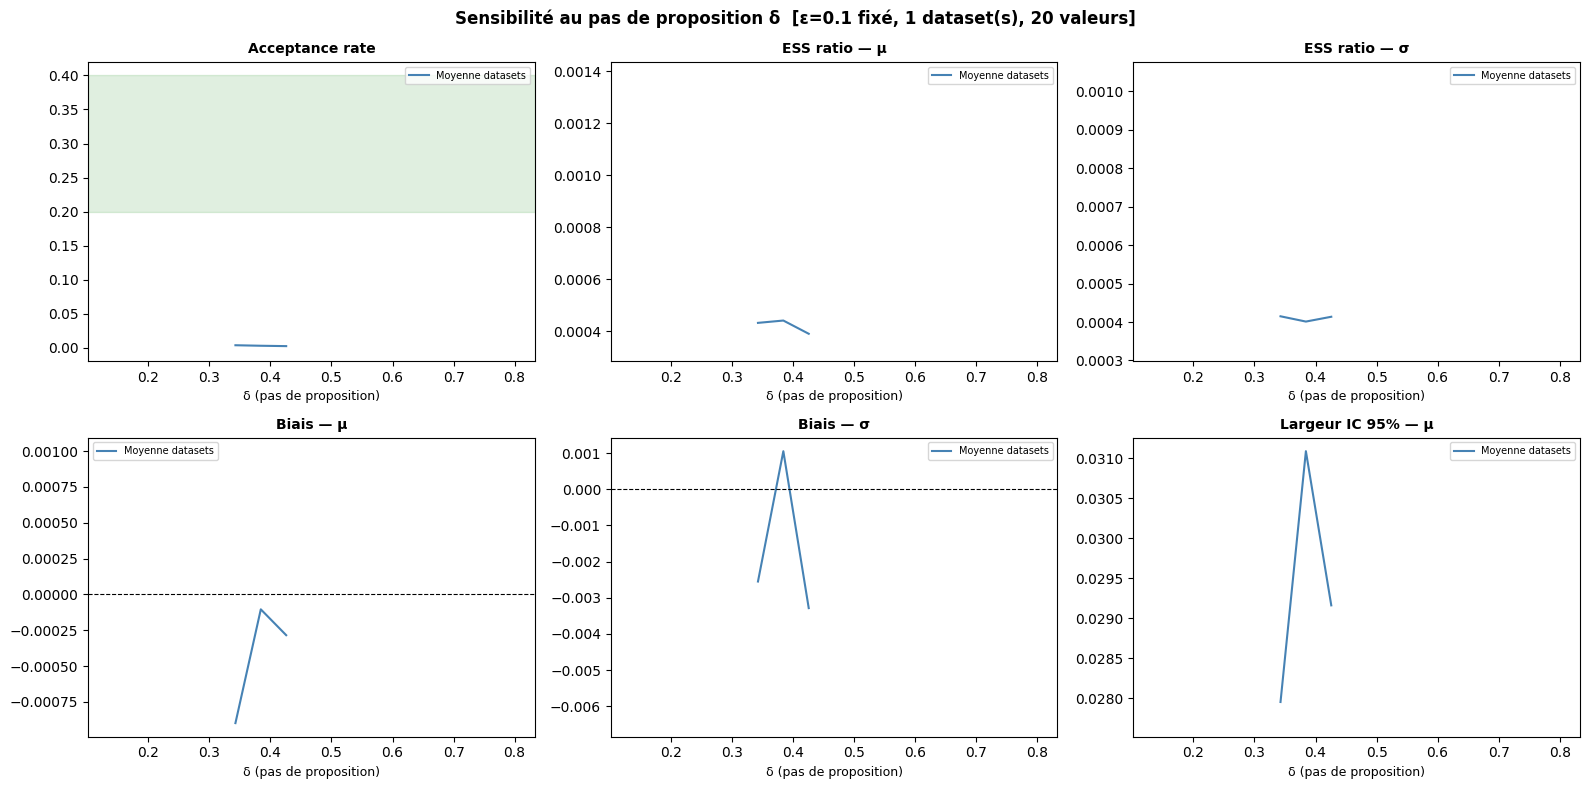

In [5]:
if SECTIONS_TO_RUN["scan_delta"]:
    print(f"{'─'*60}")
    print(f"  SECTION SCAN δ — {N_DATASETS} dataset(s) × {N_DELTAS} valeurs")
    print(f"{'─'*60}")

    DELTAS   = np.linspace(0.01, 0.8, N_DELTAS)
    EPS_FIXED = EPSILON

    results_delta = []
    key_scan_delta = random.PRNGKey(200)

    for delta in tqdm(DELTAS, desc="Scan δ"):
        key_scan_delta, k_base = random.split(key_scan_delta)
        per_ds = []
        k = k_base

        def _propose_delta(key, theta, d=delta):
            mu, sigma = theta[0], theta[1]
            key_mu, key_sig = jax.random.split(key)
            mu_new   = mu + d * jax.random.normal(key_mu)
            lsig_new = jnp.log(sigma) + d * jax.random.normal(key_sig)
            return jnp.array([mu_new, jnp.exp(lsig_new)])

        def make_mcmc_abc_delta(y_obs_sorted, epsilon, propose_fn,
                                m_sim=M_SIM, l=L):
            def body_fun(i, state):
                samples, theta_curr, key, n_acc = state
                key, kp, ks, ka = jax.random.split(key, 4)
                theta_new = propose_fn(kp, theta_curr)
                y_sim = simulate(ks, theta_new, m_sim, l)
                d_val = wasserstein1(y_obs_sorted, y_sim)
                eps_ok = (d_val <= epsilon)
                log_h  = log_prior(theta_new) - log_prior(theta_curr)
                log_u  = jnp.log(jax.random.uniform(ka))
                accept = eps_ok & (log_h > log_u)
                theta_curr = jnp.where(accept, theta_new, theta_curr)
                n_acc = n_acc + jnp.where(accept, 1, 0)
                samples = samples.at[i].set(theta_curr)
                return samples, theta_curr, key, n_acc

            def single(key, theta0, n_total=N_BURN + N_ITER):
                samples = jnp.zeros((n_total, 2)).at[0].set(theta0)
                n_acc   = jnp.array(0)
                samples, _, _, n_acc = jax.lax.fori_loop(
                    1, n_total, body_fun, (samples, theta0, key, n_acc)
                )
                return samples, n_acc / (n_total - 1)
            return single

        for ds in DATASETS:
            k, k_init, k_run = random.split(k, 3)
            try:
                theta0_d, _ = find_valid_init(
                    k_init, ds["y_obs_sorted"], EPS_FIXED
                )
                fn_d = make_mcmc_abc_delta(
                    ds["y_obs_sorted"], EPS_FIXED, _propose_delta
                )
                t0 = time.perf_counter()
                chains_d, acc_d = run_all_chains(fn_d, k_run, theta0_d)
                elapsed = time.perf_counter() - t0
                m = compute_all_metrics(chains_d, acc_d)
                m["wall_time_s"] = elapsed
                per_ds.append(m)
            except RuntimeError:
                pass

        if len(per_ds) == 0:
            results_delta.append({"delta": float(delta)})
            continue

        agg = aggregate_metrics_over_datasets(per_ds)
        agg["delta"]    = float(delta)
        agg["n_success"] = len(per_ds)
        results_delta.append(agg)

    df_delta = pd.DataFrame(results_delta)
    print(f"  Scan δ terminé. {len(df_delta)} configurations.")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle(
        f"Sensibilité au pas de proposition δ  "
        f"[ε={EPS_FIXED} fixé, {N_DATASETS} dataset(s), {N_DELTAS} valeurs]",
        fontsize=12, fontweight="bold"
    )

    d_vals = df_delta["delta"].values

    plots_d = [
        (axes[0,0], "acc_mean",         "Acceptance rate"),
        (axes[0,1], "ess_ratio_mu",     "ESS ratio — μ"),
        (axes[0,2], "ess_ratio_sigma",  "ESS ratio — σ"),
        (axes[1,0], "bias_mu",          "Biais — μ"),
        (axes[1,1], "bias_sigma",       "Biais — σ"),
        (axes[1,2], "ic95_width_mu",    "Largeur IC 95% — μ"),
    ]

    for ax, col, title in plots_d:
        col_mean   = f"{col}_mean"
        col_std_ds = f"{col}_std_ds"

        if col_mean not in df_delta.columns:
            ax.set_visible(False)
            continue

        y = df_delta[col_mean].values
        ax.plot(d_vals, y, lw=1.5, color="steelblue", label="Moyenne datasets")

        if col_std_ds in df_delta.columns and N_DATASETS > 1:
            sd = df_delta[col_std_ds].fillna(0).values
            ax.fill_between(d_vals, y - sd, y + sd,
                            alpha=0.25, color="steelblue",
                            label="± std inter-datasets")

        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_xlabel("δ (pas de proposition)", fontsize=9)
        ax.legend(fontsize=7)

        if col == "acc_mean":
            ax.axhspan(0.20, 0.40, alpha=0.12, color="green")
        if "bias" in col:
            ax.axhline(0, color="k", lw=0.8, ls="--")

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/sensitivity_delta_multids.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 6. Temps de calcul — scaling N_ITER et N_CHAINS

Cette section utilise un seul dataset de référence (le premier),
car le scaling temporel ne dépend pas du choix du dataset.

────────────────────────────────────────────────────────────
  SECTION SCALING — dataset de référence (idx=0)
────────────────────────────────────────────────────────────


Scaling N_CHAINS: 100%|██████████| 24/24 [51:12<00:00, 128.00s/it]


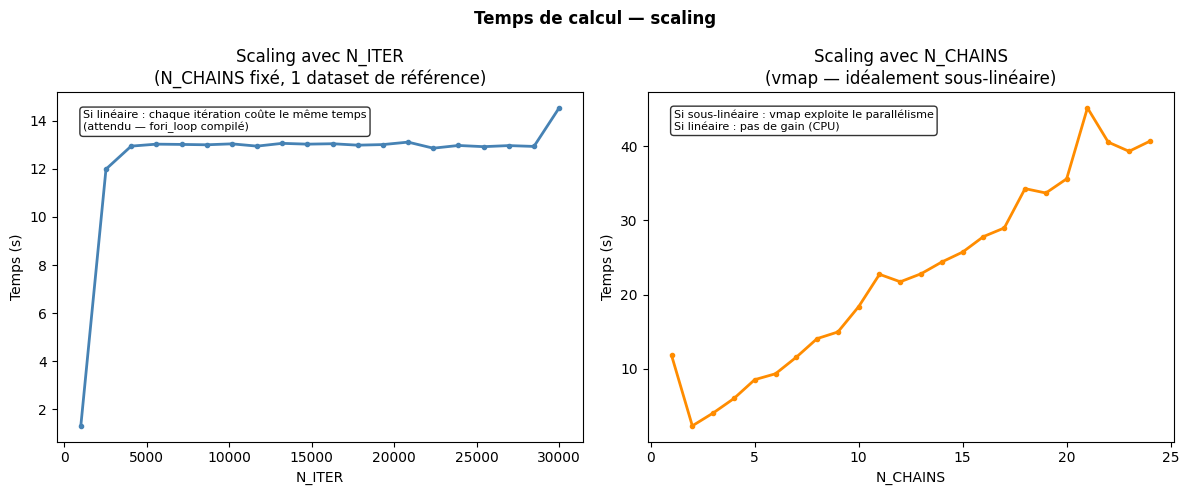

In [9]:
if SECTIONS_TO_RUN["scaling_time"]:
    print(f"{'─'*60}")
    print(f"  SECTION SCALING — dataset de référence (idx=0)")
    print(f"{'─'*60}")

    ds_ref   = DATASETS[0]
    fn_time  = make_mcmc_abc(ds_ref["y_obs_sorted"], EPSILON)
    theta0_t, key_t = find_valid_init(
        random.PRNGKey(400), ds_ref["y_obs_sorted"], EPSILON
    )

    # Scaling N_ITER
    N_ITER_VALS = np.unique(
        np.round(np.linspace(1000, 30_000, N_NITER_SCALING)).astype(int)
    )
    times_niter = []

    for n_it in tqdm(N_ITER_VALS, desc="Scaling N_ITER"):
        key_t, k_run = random.split(key_t)
        subkeys = random.split(k_run, N_CHAINS)
        mcmc_vmap = jax.vmap(fn_time, in_axes=(0, None, None))
        _ = mcmc_vmap(subkeys, theta0_t, N_BURN + 100)  # warmup JIT
        t0 = time.perf_counter()
        _ = mcmc_vmap(subkeys, theta0_t, N_BURN + int(n_it))
        elapsed = time.perf_counter() - t0
        times_niter.append({"n_iter": int(n_it), "time_s": elapsed})

    df_time_niter = pd.DataFrame(times_niter)

    # Scaling N_CHAINS
    N_CHAINS_VALS = list(range(1, N_NCHAINS_SCALING + 1))
    times_nchains = []
    key_c = random.PRNGKey(500)

    for n_ch in tqdm(N_CHAINS_VALS, desc="Scaling N_CHAINS"):
        key_c, k_run = random.split(key_c)
        subkeys = random.split(k_run, n_ch)
        mcmc_vmap = jax.vmap(fn_time, in_axes=(0, None, None))
        _ = mcmc_vmap(subkeys, theta0_t, N_BURN + 1000)  # warmup
        t0 = time.perf_counter()
        _ = mcmc_vmap(subkeys, theta0_t, N_BURN + N_ITER)
        elapsed = time.perf_counter() - t0
        times_nchains.append({"n_chains": n_ch, "time_s": elapsed})

    df_time_nchains = pd.DataFrame(times_nchains)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Temps de calcul — scaling", fontsize=12, fontweight="bold")

    axes[0].plot(df_time_niter["n_iter"], df_time_niter["time_s"],
                 lw=2, color="steelblue", marker="o", ms=3)
    axes[0].set_xlabel("N_ITER")
    axes[0].set_ylabel("Temps (s)")
    axes[0].set_title("Scaling avec N_ITER\n(N_CHAINS fixé, 1 dataset de référence)")
    axes[0].text(
        0.05, 0.95,
        "Si linéaire : chaque itération coûte le même temps\n(attendu — fori_loop compilé)",
        transform=axes[0].transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8)
    )

    axes[1].plot(df_time_nchains["n_chains"], df_time_nchains["time_s"],
                 lw=2, color="darkorange", marker="o", ms=3)
    axes[1].set_xlabel("N_CHAINS")
    axes[1].set_ylabel("Temps (s)")
    axes[1].set_title("Scaling avec N_CHAINS\n(vmap — idéalement sous-linéaire)")
    axes[1].text(
        0.05, 0.95,
        "Si sous-linéaire : vmap exploite le parallélisme\nSi linéaire : pas de gain (CPU)",
        transform=axes[1].transAxes, fontsize=8, va="top",
        bbox=dict(boxstyle="round", fc="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.savefig("MCMC-ABC_plots/scaling_time_multids.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 7. Tableau récapitulatif global

Chaque ligne présente la valeur baseline (moyenne sur N_DATASETS) +
la std inter-datasets (nouvelle colonne) + la std Monte Carlo (intra-dataset).

**Interprétation des deux types de std :**
- std inter-datasets >> std MC : le résultat dépend beaucoup du dataset tiré
  → augmenter N_DATASETS pour mieux caractériser la distribution du posterior
- std MC >> std inter-datasets : la chaîne est peu efficace
  → augmenter N_ITER ou optimiser δ

In [10]:
if SECTIONS_TO_RUN["summary_table"] and SECTIONS_TO_RUN["baseline"]:
    rows = [
        {
            "Métrique": "Biais μ",
            "Définition": "médiane postérieure − vraie valeur",
            "Valeur (moy. datasets)": f"{agg_base.get('bias_mu_mean', float('nan')):+.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('bias_mu_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Réduire ε",
        },
        {
            "Métrique": "Biais σ",
            "Définition": "médiane postérieure − vraie valeur",
            "Valeur (moy. datasets)": f"{agg_base.get('bias_sigma_mean', float('nan')):+.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('bias_sigma_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Réduire ε",
        },
        {
            "Métrique": "Std posterior μ  (A)",
            "Définition": "Largeur de p(μ|Y) — moy. sur datasets",
            "Valeur (moy. datasets)": f"{agg_base.get('std_posterior_mu_mean', float('nan')):.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('std_posterior_mu_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Plus de données, ε plus petit",
        },
        {
            "Métrique": "Std MC médiane μ  (B)",
            "Définition": "Stabilité estimateur — moy. sur datasets",
            "Valeur (moy. datasets)": f"{agg_base.get('std_mc_median_mu_mean', float('nan')):.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('std_mc_median_mu_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Plus d'itérations, plus de chaînes",
        },
        {
            "Métrique": "Largeur IC 95% μ",
            "Définition": "q97.5 − q2.5 — moy. sur datasets",
            "Valeur (moy. datasets)": f"{agg_base.get('ic95_width_mu_mean', float('nan')):.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('ic95_width_mu_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Réduire ε, plus de données",
        },
        {
            "Métrique": "R-hat μ",
            "Définition": "Convergence inter-chaînes (cible < 1.01)",
            "Valeur (moy. datasets)": f"{agg_base.get('rhat_mu_mean', float('nan')):.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('rhat_mu_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Plus de burn-in, meilleur δ",
        },
        {
            "Métrique": "ESS ratio μ",
            "Définition": "ESS / N_total — moy. sur datasets",
            "Valeur (moy. datasets)": f"{agg_base.get('ess_ratio_mu_mean', float('nan')):.4f}",
            "Std inter-datasets (C)": f"{agg_base.get('ess_ratio_mu_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Optimiser δ (acceptance 20–40%)",
        },
        {
            "Métrique": "Acceptance rate",
            "Définition": "Proportion proposals acceptés",
            "Valeur (moy. datasets)": f"{agg_base.get('acc_mean_mean', float('nan')):.3f}",
            "Std inter-datasets (C)": f"{agg_base.get('acc_mean_std_ds', float('nan')):.4f}",
            "Comment l'améliorer": "Ajuster δ",
        },
        {
            "Métrique": "Temps par dataset",
            "Définition": "Wall time moyen (N_CHAINS chaînes en ||)",
            "Valeur (moy. datasets)": f"{agg_base.get('wall_time_s_mean', float('nan')):.1f}s",
            "Std inter-datasets (C)": f"{agg_base.get('wall_time_s_std_ds', float('nan')):.2f}s",
            "Comment l'améliorer": "Réduire N_ITER, utiliser GPU",
        },
    ]

    summary = pd.DataFrame(rows)
    pd.set_option("display.max_colwidth", 55)
    pd.set_option("display.width", 130)

    print("\n" + "═" * 90)
    print(f"  TABLEAU RÉCAPITULATIF — MCMC-ABC  "
          f"[N_DATASETS={N_DATASETS}, ε={EPSILON}]")
    print("═" * 90)
    print(f"\n  LÉGENDE des colonnes std :")
    print(f"  (A) Std du posterior    : largeur de p(θ|Y) — incertitude sur θ lui-même")
    print(f"  (B) Std Monte Carlo     : stabilité de l'estimateur entre chaînes")
    print(f"  (C) Std inter-datasets  : variabilité due au choix de Y_OBS "
          f"{'(non estimable, N_DATASETS=1)' if N_DATASETS == 1 else ''}")
    print(f"\n  Interprétation (C) vs (B) :")
    print(f"  Si (C) >> (B) : résultat sensible au dataset → augmenter N_DATASETS")
    print(f"  Si (B) >> (C) : chaîne peu efficace → augmenter N_ITER ou optimiser δ\n")
    display(summary)


══════════════════════════════════════════════════════════════════════════════════════════
  TABLEAU RÉCAPITULATIF — MCMC-ABC  [N_DATASETS=1, ε=0.1]
══════════════════════════════════════════════════════════════════════════════════════════

  LÉGENDE des colonnes std :
  (A) Std du posterior    : largeur de p(θ|Y) — incertitude sur θ lui-même
  (B) Std Monte Carlo     : stabilité de l'estimateur entre chaînes
  (C) Std inter-datasets  : variabilité due au choix de Y_OBS (non estimable, N_DATASETS=1)

  Interprétation (C) vs (B) :
  Si (C) >> (B) : résultat sensible au dataset → augmenter N_DATASETS
  Si (B) >> (C) : chaîne peu efficace → augmenter N_ITER ou optimiser δ



,Métrique,Définition,Valeur (moy. datasets),Std inter-datasets (C),Comment l'améliorer
0,Biais μ,médiane postérieure − vraie valeur,-0.0004,nan,Réduire ε
1,Biais σ,médiane postérieure − vraie valeur,-0.0026,nan,Réduire ε
2,Std posterior μ (A),Largeur de p(μ|Y) — moy. sur datasets,0.0077,nan,"Plus de données, ε plus petit"
3,Std MC médiane μ (B),Stabilité estimateur — moy. sur datasets,0.0006,nan,"Plus d'itérations, plus de chaînes"
4,Largeur IC 95% μ,q97.5 − q2.5 — moy. sur datasets,0.0292,nan,"Réduire ε, plus de données"
5,R-hat μ,Convergence inter-chaînes (cible < 1.01),1.0029,nan,"Plus de burn-in, meilleur δ"
6,ESS ratio μ,ESS / N_total — moy. sur datasets,0.0019,nan,Optimiser δ (acceptance 20–40%)
7,Acceptance rate,Proportion proposals acceptés,0.036,nan,Ajuster δ
8,Temps par dataset,Wall time moyen (N_CHAINS chaînes en ||),1.2s,nans,"Réduire N_ITER, utiliser GPU"
